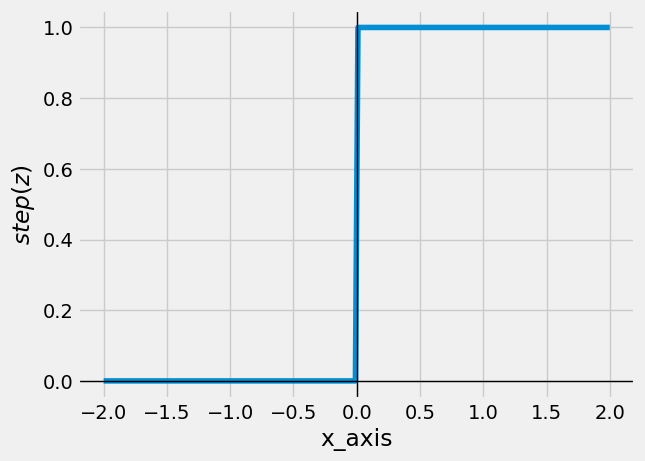

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("fivethirtyeight")

x_axis = np.linspace(-2,2,200)
step = np.where(x_axis < 0, 0, 1)

plt.plot(x_axis, step)
plt.xlabel("x_axis")
plt.ylabel(r"$step(z)$")
plt.axhline(0, color='k', lw=1);
plt.axvline(0, color='k', lw=1);

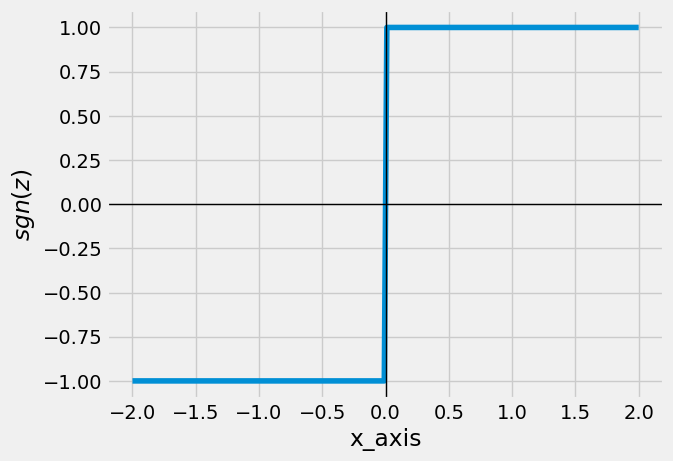

In [2]:
def sgn(x):
    if x < 0:
        return -1
    elif x > 0:
        return 1
    return 0

sgn = np.array(list(map(sgn, x_axis)))

plt.plot(x_axis, sgn)
plt.xlabel("x_axis")
plt.ylabel(r"$sgn(z)$")
plt.axhline(0, color='k', lw=1);
plt.axvline(0, color='k', lw=1);

In [3]:
# Implementation of Perceptron with Python
import joblib
import pandas as pd
plt.style.use("fivethirtyeight")

In [4]:
class Perceptron:
  def __init__(self, eta, epochs):
    self.weights = np.random.randn(3) * 1e-4
    print(f"self.weights: {self.weights}")
    self.eta = eta
    self.epochs = epochs

  def activationFunction(self, inputs, weights):
    z = np.dot(inputs, weights)
    return np.where(z > 0 , 1, 0)

  def fit(self, X, y):
    self.X = X
    self.y = y

    X_with_bias = np.c_[self.X, -np.ones((len(self.X), 1))] # concactination
    print(f"X_with_bias: \n{X_with_bias}")

    for epoch in range(self.epochs):
      print(f"for epoch: {epoch}")
      y_hat = self.activationFunction(X_with_bias, self.weights)
      print(f"predicted value: \n{y_hat}")
      error = self.y - y_hat
      print(f"error: \n{error}")
      self.weights = self.weights + self.eta * np.dot(X_with_bias.T, error)
      print(f"updated weights: \n{self.weights}")
      print("#############\n")

  def predict(self, X):
    X_with_bias = np.c_[X, -np.ones((len(self.X), 1))]
    return self.activationFunction(X_with_bias, self.weights)

In [5]:
# AND
data = {"x1": [0,0,1,1], "x2": [0,1,0,1], "y": [0,0,0,1]}

AND = pd.DataFrame(data)
AND

,x1,x2,y
0,0,0,0
1,0,1,0
2,1,0,0
3,1,1,1


In [6]:
X = AND.drop("y", axis=1)
X

,x1,x2
0,0,0
1,0,1
2,1,0
3,1,1


In [7]:
y = AND['y']
y.to_frame()

,y
0,0
1,0
2,0
3,1


In [8]:
model = Perceptron(eta = 0.5, epochs=10)
model.fit(X,y)

self.weights: [ 5.60652360e-05 -1.20505237e-04  1.40224239e-04]
X_with_bias: 
[[ 0.  0. -1.]
 [ 0.  1. -1.]
 [ 1.  0. -1.]
 [ 1.  1. -1.]]
for epoch: 0
predicted value: 
[0 0 0 0]
error: 
0    0
1    0
2    0
3    1
Name: y, dtype: int64
updated weights: 
[ 0.50005607  0.49987949 -0.49985978]
#############

for epoch: 1
predicted value: 
[1 1 1 1]
error: 
0   -1
1   -1
2   -1
3    0
Name: y, dtype: int64
updated weights: 
[ 5.60652360e-05 -1.20505237e-04  1.00014022e+00]
#############

for epoch: 2
predicted value: 
[0 0 0 0]
error: 
0    0
1    0
2    0
3    1
Name: y, dtype: int64
updated weights: 
[0.50005607 0.49987949 0.50014022]
#############

for epoch: 3
predicted value: 
[0 0 0 1]
error: 
0    0
1    0
2    0
3    0
Name: y, dtype: int64
updated weights: 
[0.50005607 0.49987949 0.50014022]
#############

for epoch: 4
predicted value: 
[0 0 0 1]
error: 
0    0
1    0
2    0
3    0
Name: y, dtype: int64
updated weights: 
[0.50005607 0.49987949 0.50014022]
#############

for epoc

In [9]:
model.predict(X)

array([0, 0, 0, 1])

In [10]:
# Saving and Loading model
import os
# saving model
dir_ = "Perceptron_model"
os.makedirs(dir_, exist_ok=True)
filename = os.path.join(dir_, 'AND_model.model')
joblib.dump(model, filename)

['Perceptron_model\\AND_model.model']

In [ ]:
# load the model
loaded_model = joblib.load(filename)
result = loaded_model.predict(X)
print(result)

[0 0 0 1]


In [12]:
# OR Operation
data = {"x1": [0,0,1,1], "x2": [0,1,0,1], "y": [0,1,1,1]}

OR = pd.DataFrame(data)
OR

,x1,x2,y
0,0,0,0
1,0,1,1
2,1,0,1
3,1,1,1


In [13]:
X = OR.drop("y", axis=1)
X

,x1,x2
0,0,0
1,0,1
2,1,0
3,1,1
